In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import warnings
warnings.simplefilter("ignore")
# parentdir = os.path.abspath('../..')
# sys.path.insert(0, parentdir) 
from herculens_import_main import *
import jax
import numpyro
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_FLAGS'] = (
    '--xla_gpu_enable_triton_softmax_fusion=true '
    '--xla_gpu_triton_gemm_any=True '
    '--xla_gpu_enable_async_collectives=true '
    '--xla_gpu_enable_latency_hiding_scheduler=true '
    '--xla_gpu_enable_highest_priority_async_stream=true '
)
if 'graphviz' not in os.environ['PATH']:
    os.environ['PATH'] = '/opt/apps/pkgs/graphviz/12.2.1/intel64/gnu_12.2.0/bin:' + os.environ['PATH']

[CudaDevice(id=0)]


In [2]:
pix_scale = 0.05  # arcsec / pixel (HST)

DATA_DIR = "../../Data/RXJ1131"
raw_data_path = os.path.join(DATA_DIR, "j8oi74010_drc.fits")
data_path = os.path.join(DATA_DIR, "j8oi74010_drc_cut_x2116_y3377_200_scierr_corner5.fits")
mask_path = os.path.join(DATA_DIR, "mask.fits")

with fits.open(raw_data_path, memmap=True) as hdul_raw:
    exposure_time = float(hdul_raw[0].header.get("EXPTIME", hdul_raw[0].header.get("TEXPTIME", 1.0)))

with fits.open(data_path, memmap=True) as hdul:
    data = jnp.array(hdul["SCI"].data) if "SCI" in hdul else jnp.array(hdul[0].data)
    rms_file = jnp.array(hdul["ERR"].data)

mask = jnp.array(fits.getdata(mask_path), dtype=bool)
mask_out = jnp.ones_like(data, dtype=bool)
mask = jnp.array(mask_out, dtype=bool)

valid = jnp.isfinite(data) & jnp.isfinite(rms_file) & (rms_file > 0)
mask = mask & valid
npix = int(mask_out.sum())

corner_pixel = 10
bkg_corner = np.array(data[:corner_pixel, :corner_pixel])
bkg_mean = float(np.nanmean(bkg_corner))
bkg_rms = float(np.nanstd(bkg_corner))

data = data - bkg_mean
rms = float(np.nanmedian(np.array(rms_file[mask_out])))

# Assume Step 3 PSF output format is as expected
psf_path_model = os.path.join("./psf_data", "PSF_model_step3_svi.fits")
with fits.open(psf_path_model, memmap=True) as hdul_psf:
    psf_hst = np.array(hdul_psf["DET_PSF_MODEL"].data, dtype=float)

psf_hst = np.clip(psf_hst, 0.0, None)
psf_hst = psf_hst / np.sum(psf_hst)
psf_used = psf_path_model
psf = PSF(psf_type='PIXEL', kernel_point_source=psf_hst)

pixel_grid, xgrid, ygrid, x_axis, y_axis, extent, nx, ny = get_pixel_grid(data, pix_scale)
noise = Noise(nx, ny, exposure_time=exposure_time)
provided_rms = True

N_gauss_light = 8
N_gauss_source = 1

sigma_lims_lens = [0.01, 3.0]
sigma_lims = [0.01, 0.5]

lens_light_ps_pos = jnp.array([0.5, -0.1])

source_grid_scale = 0.7

conj_points = jnp.array([
    [0.26298137209467, 2.09255496979808],
    [1.35258643634931, 1.62712406079166],
    [-1.00020401055449, 2.01497731965513],
    [-0.22609309020619, -1.10668714778579],
])

ss_factor = 2

PSF_CORNER_SIZE = 5

def compute_psf_corner_median(psf_kernel, corner_size=PSF_CORNER_SIZE):
    ny, nx = psf_kernel.shape
    cs = min(corner_size, ny, nx)
    corners = np.concatenate([
        psf_kernel[:cs, :cs].reshape(-1),
        psf_kernel[:cs, -cs:].reshape(-1),
        psf_kernel[-cs:, :cs].reshape(-1),
        psf_kernel[-cs:, -cs:].reshape(-1),
    ])
    return float(np.nanmedian(corners))

psf_corner_median = compute_psf_corner_median(psf_hst, corner_size=PSF_CORNER_SIZE)

def subtract_psf_corner_median(model_image, psf_median=psf_corner_median):
    return model_image - jnp.asarray(psf_median, dtype=model_image.dtype)



In [3]:
# Prior config block
MASS_PRIOR_PARAMETRIC = {
    'gamma_low': 1.95,
    'gamma_up': 2.05,
    'center_high': 0.5,
    'center_low': -0.5,
}

MASS_PRIOR_PIXELATED = {}

LENS_LIGHT_PRIOR_KWARGS = {
    'plate_name': 'Lens light',
    'param_name': 'lens',
    'n_gauss': N_gauss_light,
    'sigma_lims': sigma_lims_lens,
    'e_low': -0.2,
    'e_high': 0.2,
}

POINT_SOURCE_PRIOR = {
    'pos_sigma': 0.05,
    'pos_window': 0.2,
    'log10_amp_low': -3.0,
    'log10_amp_high': 4.5,
    'log10_amp_lens_low': -3.0,
    'log10_amp_lens_high': 4.5,
}

CONJUGATE_POINT_PRIOR = {
    'rate': {
        'parametric': 1000.0,
        'pixelated': 100.0,
    },
}

RMS_PRIOR = {
    'low_factor': 0.5,
    'high_factor': 1.5,
}

SOURCE_GRID_PRIOR = {
    'plate_name': 'Source grid',
    'param_name': 'source_grid',
    'n_high': 1000,
    'positive': True,
}



In [4]:
# Data-loading diagnostics removed by design.


In [5]:
from herculens.PointSourceModel.point_source_model import PointSourceModel

mass_model = MassModel(['EPL', 'SHEAR'])

lens_light_model = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

source_light_model = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

point_source_model = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model,
    image_plane=pixel_grid,
)

lens_image = LensImageExtension(
    pixel_grid,
    psf,
    noise_class=noise,
    lens_light_model_class=lens_light_model,
    lens_mass_model_class=mass_model,
    source_model_class=source_light_model,
    point_source_model_class=point_source_model,
    source_arc_mask=mask,
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale = source_grid_scale
)


In [6]:
npix = int(mask_out.sum())
N_HIGH_SOURCE_GRID = SOURCE_GRID_PRIOR['n_high']

def model(data, k_values=None, conj=True, provided_rms=False, pixelated=False, n_value=None, mass_prior_kwargs={}, psf_kernel_point_source=None):
    mass_params = EPL_w_shear('Mass model', '1', **mass_prior_kwargs)
    lens_light = multi_gauss_light(**LENS_LIGHT_PRIOR_KWARGS)

    n_ps = conj_points.shape[0]
    ra_ps = numpyro.sample(
        'ra_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 0],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 0] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 0] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    dec_ps = numpyro.sample(
        'dec_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 1],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 1] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 1] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    log10_amp_ps = numpyro.sample(
        'log10_amp_ps',
        dist.Uniform(
            POINT_SOURCE_PRIOR['log10_amp_low'],
            POINT_SOURCE_PRIOR['log10_amp_high'],
        ).expand([n_ps]),
    )
    log10_amp_lens_ps = numpyro.sample(
        'log10_amp_lens_ps',
        dist.Uniform(
            POINT_SOURCE_PRIOR['log10_amp_lens_low'],
            POINT_SOURCE_PRIOR['log10_amp_lens_high'],
        ),
    )

    amp_quasar_ps = jnp.power(10.0, log10_amp_ps)
    amp_lens_ps = jnp.power(10.0, log10_amp_lens_ps)
    kwargs_point_source = [{
        'ra': jnp.concatenate([ra_ps, jnp.array([lens_light_ps_pos[0]])]),
        'dec': jnp.concatenate([dec_ps, jnp.array([lens_light_ps_pos[1]])]),
        'amp': jnp.concatenate([amp_quasar_ps, jnp.array([amp_lens_ps])]),
    }]

    lens_img = lens_image_pixel if pixelated else lens_image

    if conj:
        conj_points_model = lens_img.trace_conjugate_points(mass_params)
        conj_distance = reduced_distance_matrix(conj_points_model)
        nc = conj_distance.shape[0]
        rate_key = 'pixelated' if pixelated else 'parametric'
        conj_rate = CONJUGATE_POINT_PRIOR['rate'][rate_key]
        with numpyro.plate(f'Conjugate points 2 - [{nc}]', nc):
            numpyro.sample('conjugate_points', dist.Exponential(conj_rate), obs=conj_distance)

    if pixelated:
        if k_values is None:
            raise ValueError('k_values is required when pixelated=True')
        source_light = [
            matern_power_spectrum(
                SOURCE_GRID_PRIOR['plate_name'],
                SOURCE_GRID_PRIOR['param_name'],
                k_values,
                n_high=SOURCE_GRID_PRIOR['n_high'],
                n_value=n_value,
                positive=SOURCE_GRID_PRIOR['positive'],
            )
        ]
    else:
        conj_points_model_for_center = lens_image.trace_conjugate_points(mass_params)
        source_center = jnp.mean(conj_points_model_for_center, axis=0)
        source_light = multi_gauss_light_center(
            'Source light',
            'source',
            N_gauss_source,
            sigma_lims,
            center_det=source_center,
        )

    model_image = lens_img.model(
        kwargs_lens=mass_params,
        kwargs_source=source_light,
        kwargs_lens_light=lens_light,
        kwargs_point_source=kwargs_point_source,
        source_add=True,
        point_source_add=True,
        psf_kernel_point_source=psf_kernel_point_source,
    )

    if provided_rms:
        model_std = rms_file
    else:
        background_rms_model = numpyro.sample(
            'RMS',
            dist.LogUniform(rms * RMS_PRIOR['low_factor'], rms * RMS_PRIOR['high_factor']),
        )
        model_var = lens_img.Noise.C_D_model(model_image, background_rms=background_rms_model)
        model_std = jnp.sqrt(model_var)

    model_image_masked_out = model_image[mask_out]
    model_std_masked_out = model_std[mask_out]

    numpyro.deterministic('model_image', model_image)

    with numpyro.plate(f'Data masked - [{npix}]', npix):
        numpyro.sample('obs', dist.Normal(model_image_masked_out, model_std_masked_out), obs=data[mask_out])


def params2kwargs(params, fixed_params={}, pixelated=False):
    params_full = params | fixed_params
    kwargs_lens = params2kwargs_EPL_w_shear(params_full, '1')
    kwargs_lens_light = params2kwargs_multi_gauss_light(params_full, 'lens')
    kwargs_point_source = [{
        'ra': jnp.concatenate([params_full['ra_ps'], jnp.array([lens_light_ps_pos[0]])]),
        'dec': jnp.concatenate([params_full['dec_ps'], jnp.array([lens_light_ps_pos[1]])]),
        'amp': jnp.concatenate([
            jnp.power(10.0, params_full['log10_amp_ps']),
            jnp.array([jnp.power(10.0, params_full['log10_amp_lens_ps'])]),
        ]),
    }]

    if pixelated:
        kwargs_source = [params2kwargs_power_spectrum(params_full, 'source_grid')]
    else:
        conj_points_model = lens_image.trace_conjugate_points(kwargs_lens)
        source_center = jnp.mean(conj_points_model, axis=0)
        n_source = params_full['amp_source'].shape[0]
        center_source = jnp.vstack([
            jnp.full((n_source,), source_center[0]),
            jnp.full((n_source,), source_center[1]),
        ])
        params_full = params_full | {'center_source': center_source}
        kwargs_source = params2kwargs_multi_gauss_light(params_full, 'source')

    return {
        'kwargs_lens': kwargs_lens,
        'kwargs_source': kwargs_source,
        'kwargs_lens_light': kwargs_lens_light,
        'kwargs_point_source': kwargs_point_source,
    }

model_graph = numpyro.render_model(
    model,
    model_args=(data,),
    model_kwargs={
        'pixelated': False,
        'provided_rms': provided_rms,
        'mass_prior_kwargs': MASS_PRIOR_PARAMETRIC,
    },
    render_distributions=True,
)



Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

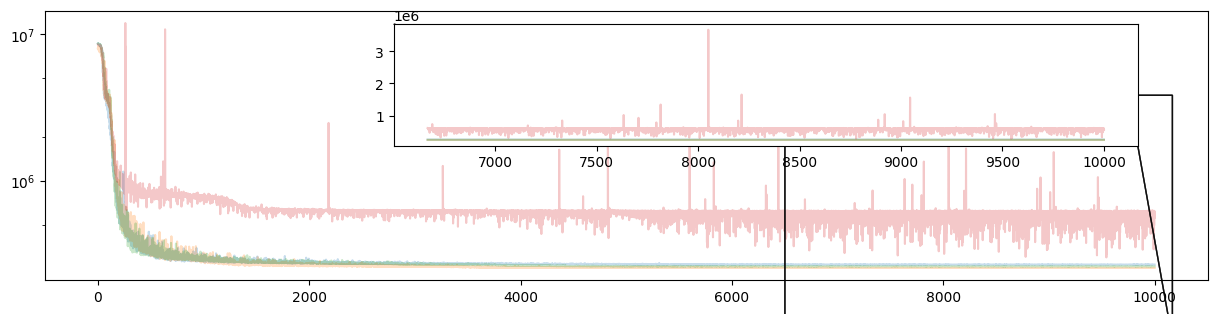

In [7]:
max_iterations = 10000
num_chains = 4

init_fun = infer.init_to_median(num_samples=25)
guide = autoguide.AutoLowRankMultivariateNormal(model, init_loc_fn=init_fun)
scheduler = split_scheduler(max_iterations, init_value=0.01, transition_steps=[200, 10])
optim = optax.adabelief(learning_rate=scheduler)
loss = infer.Trace_ELBO (num_particles=1)

rng_key = jax.random.PRNGKey(42)
rng_key, rng_key_ = jax.random.split(rng_key)
svi_keys = jax.random.split(rng_key_, num_chains)
svi = SVI_vec(model, guide, optim, loss)
multi_svi_results = svi.run(rng_key, num_chains, max_iterations, data, provided_rms=provided_rms, mass_prior_kwargs=MASS_PRIOR_PARAMETRIC, stable_update=True)
multi_svi_median = guide.median(multi_svi_results.params)

multi_svi_median_herc = median_params2kwargs(params2kwargs, multi_svi_median, jnp.arange(num_chains))


_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_results.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)

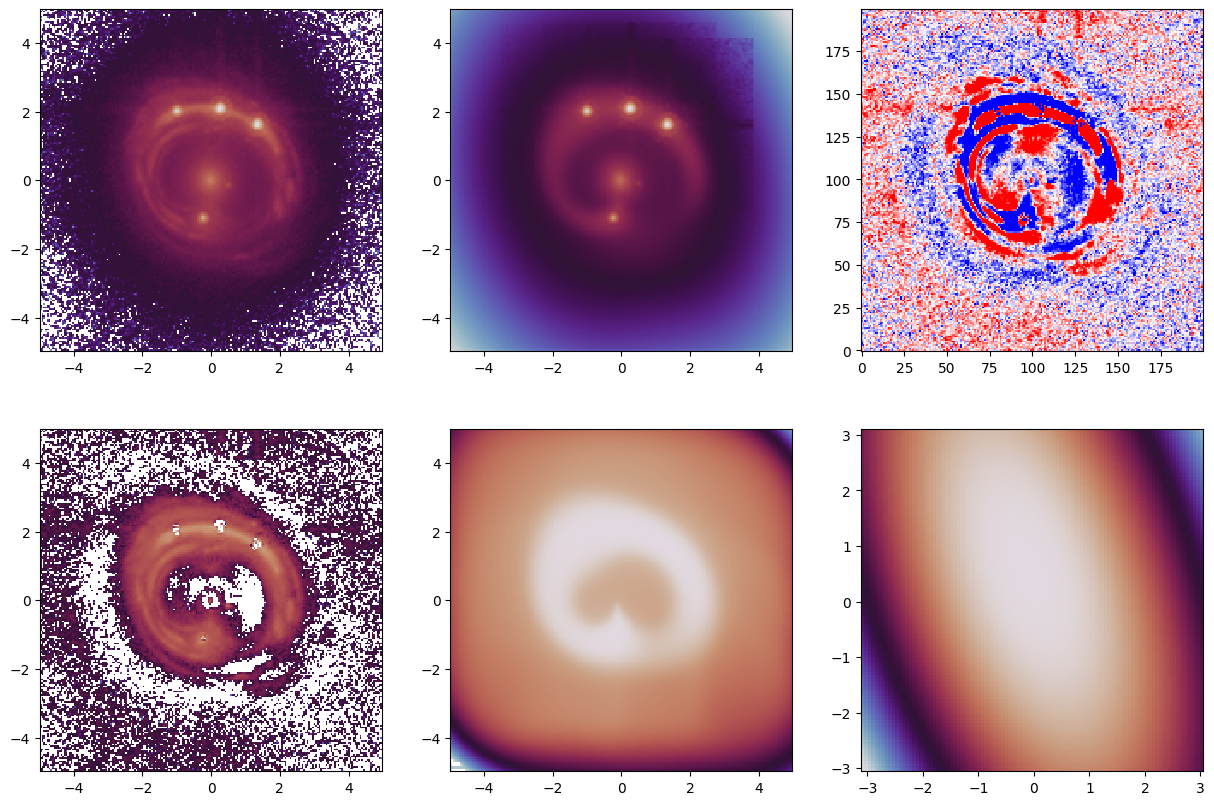

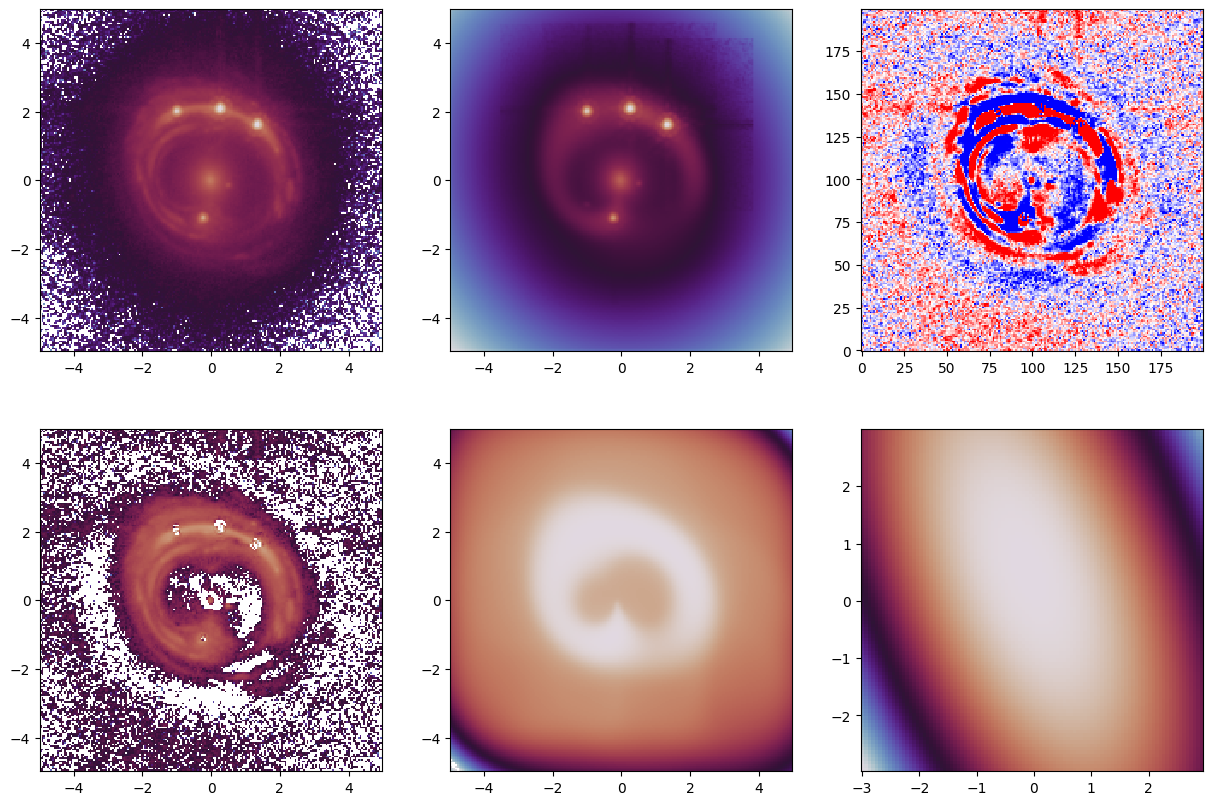

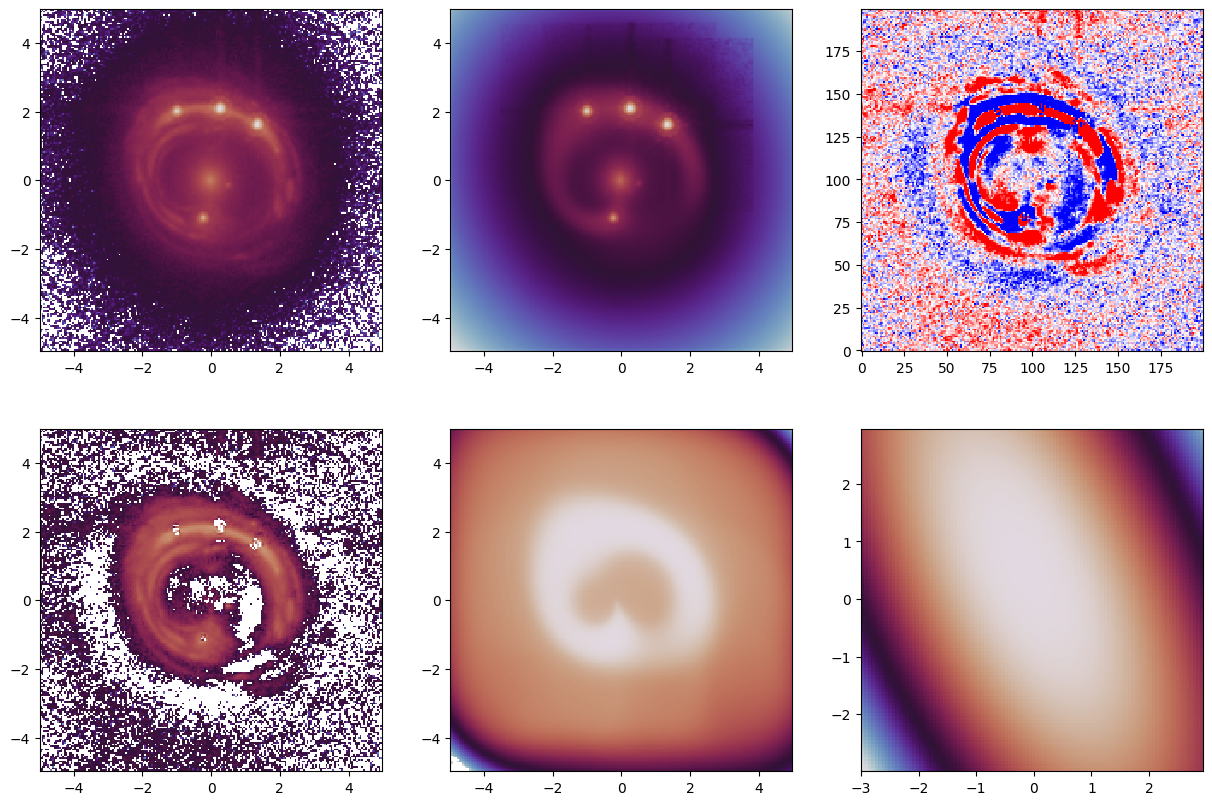

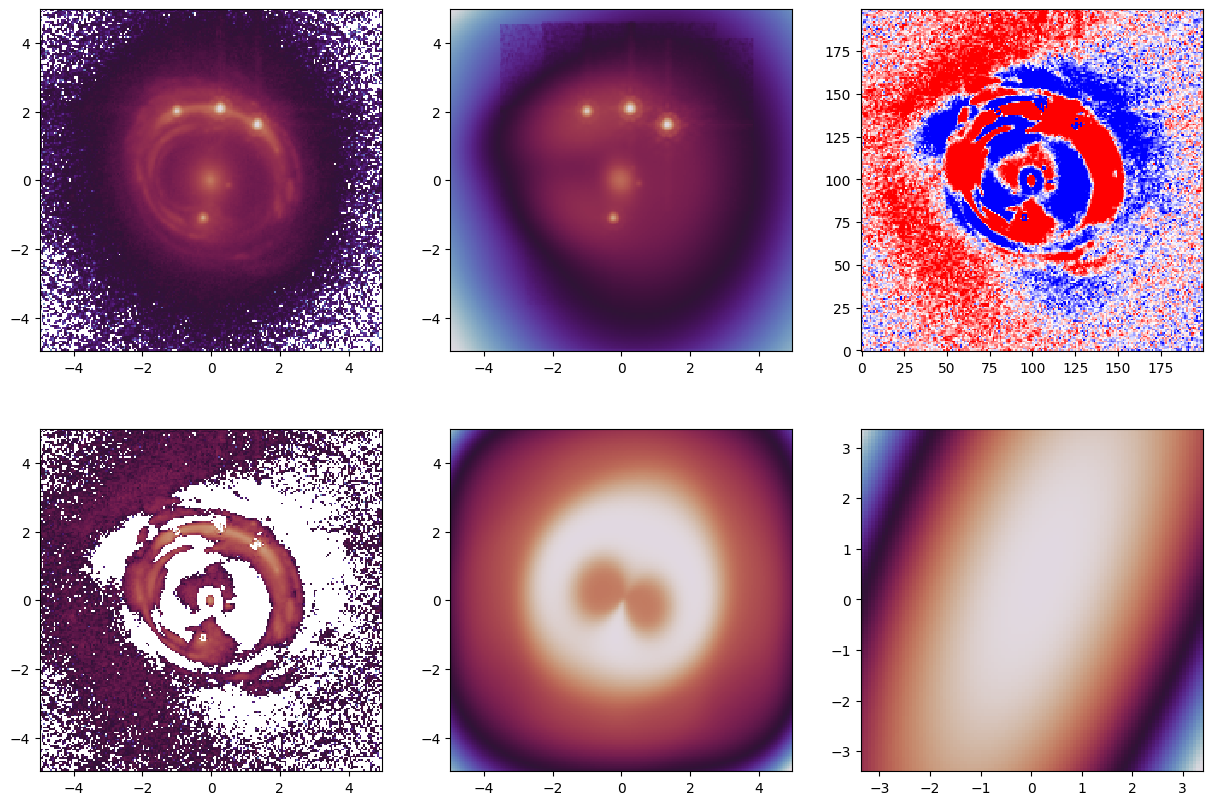

In [8]:
from lens_images_extension import pixelize_plane as pixelize_plane_single
for i in range(4):
    plt.figure(figsize = (15,10))
    plt.subplot(2,3,1)
    plt.imshow(data, norm = 'log', cmap = 'twilight', extent = extent, origin = 'lower')
    plt.subplot(2,3,2)
    image_model = lens_image.model(**get_value_from_index(multi_svi_median_herc, i), source_add = True)
    plt.imshow(image_model, norm = 'log', cmap = 'twilight', extent = extent)
    plt.subplot(2,3,3)

    plt.imshow((data - image_model)/rms_file, cmap = 'bwr', vmax = 3, vmin = -3)
    plt.subplot(2,3,4)
    lens_light = lens_image.model(**get_value_from_index(multi_svi_median_herc, i), source_add = False)
    plt.imshow(data - lens_light, norm = 'log', cmap = 'twilight', extent = extent)

    plt.subplot(2,3,5)
    plt.imshow(image_model - lens_light, norm = 'log', cmap = 'twilight', extent = extent)
    plt.subplot(2,3,6)
    source, source_extent = pixelize_plane_single(
        lens_image,
        get_value_from_index(multi_svi_median_herc, i),
        100,
    )
    plt.imshow(source, extent = source_extent, norm = 'log', cmap = 'twilight')

In [9]:
best_pix_sizes = np.array([
    get_best_pixel_size(
        lens_image,
        get_value_from_index(multi_svi_median_herc, i),
        source_grid_scale
    ) for i in range(num_chains)
])
pixel_grid_shape = np.median(best_pix_sizes).astype(int)*1
# pixel_grid_shape = 50
print(pixel_grid_shape)

100


In [10]:
vars_mass = ['theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_lens_light = ['A_lens', 'sigma_lens', 'e_lens', 'center_lens']
vars_source_light = ['A_source', 'sigma_source', 'e_source']
vars_point_source = ['ra_ps', 'dec_ps', 'log10_amp_ps', 'log10_amp_lens_ps']
vars_other = []

svi_samples = guide.sample_posterior(rng_key_, multi_svi_results.params, sample_shape=(1000,))
svi_samples_chains = jax.tree.map(lambda x: jnp.swapaxes(x, 0, 1), svi_samples)
svi_samples_chains = jax.device_get(svi_samples_chains)
multi_svi_guide_sample = az.from_dict(svi_samples_chains)

k_grid = K_grid((pixel_grid_shape, pixel_grid_shape))

@jax.vmap
def get_image(idx):
    i, _ = pixelize_plane_single(lens_image, get_value_from_index(multi_svi_median_herc, idx), pixel_grid_shape, source_grid_scale=source_grid_scale)
    return i
orig_source = get_image(jnp.arange(num_chains))
ps_keys = jax.random.split(rng_key_, num_chains)
from herculens_import_main import source_power_spectrum
ps_fits = source_power_spectrum(orig_source, ps_keys, None, True)

keys_for_pixel_init = vars_lens_light + vars_mass + vars_point_source + vars_other
multi_svi_median_pixelated = {k: multi_svi_median[k] for k in keys_for_pixel_init if k in multi_svi_median} | ps_fits



In [11]:
k_grid = K_grid((pixel_grid_shape, pixel_grid_shape))

from herculens.PointSourceModel.point_source_model import PointSourceModel

mass_model_pixel = MassModel(['EPL', 'SHEAR'])
lens_light_model_pixel = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

source_light_model_pixel = LightModel(
    ['PIXELATED',],
    pixel_adaptive_grid=True,
    pixel_interpol='fast_bilinear',
    kwargs_pixelated={'num_pixels': pixel_grid_shape}
)

pixel_grid_pixel = deepcopy(pixel_grid)
psf_pixel = deepcopy(psf)

point_source_model_pixel = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model_pixel,
    image_plane=pixel_grid_pixel,
)

lens_image_pixel = LensImageExtension(
    pixel_grid_pixel,
    psf_pixel,
    noise_class=noise,
    lens_light_model_class=lens_light_model_pixel,
    lens_mass_model_class=mass_model_pixel,
    source_model_class=source_light_model_pixel,
    point_source_model_class=point_source_model_pixel,
    source_arc_mask=mask,
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale=source_grid_scale,
)



In [12]:
npix = int(mask_out.sum())
N_HIGH_SOURCE_GRID = 1000

model_graph = numpyro.render_model(
    model,
    model_args=(data, k_grid.k),
    model_kwargs={'conj': False, 'pixelated': True, 'provided_rms': provided_rms, 'mass_prior_kwargs': MASS_PRIOR_PIXELATED},
    render_distributions=True,
)


[2026-02-24 22:34:11] running
[2026-02-24 22:36:11] running
[2026-02-24 22:38:11] running
[2026-02-24 22:40:11] running
SVI runs for 480.004 s which is 8.0 min


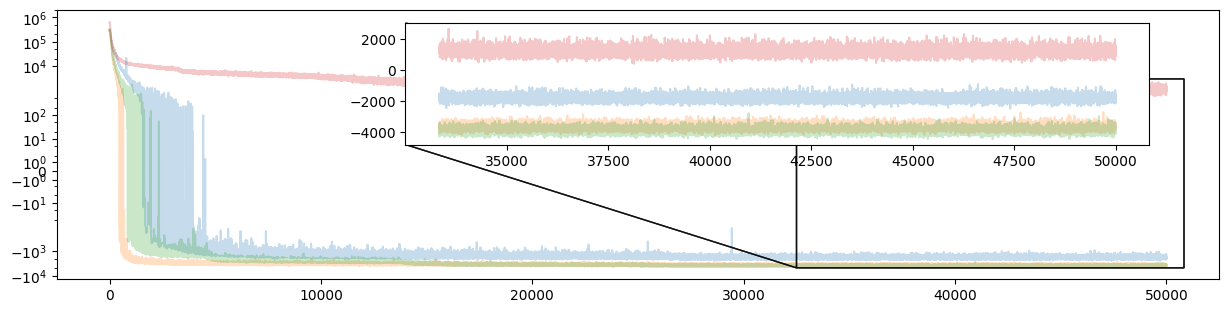

In [13]:
max_iterations = 10000
num_chains = 4

scheduler_stage1 = split_scheduler(max_iterations, init_value=0.01, transition_steps=[200, 10])
optim_stage1 = optax.adabelief(learning_rate=scheduler_stage1)
loss_stage1 = infer.TraceMeanField_ELBO()

svi_keys = jax.random.split(rng_key_, num_chains)
stage1_results_list = []
stage1_guides = []

for i in range(num_chains):
    init_fun_stage1_i = init_to_value_or_defer(values=get_value_from_index(multi_svi_median_pixelated, i))
    guide_stage1_i = autoguide.AutoDiagonalNormal(model, init_loc_fn=init_fun_stage1_i, init_scale=0.01)
    svi_stage1_i = infer.SVI(model, guide_stage1_i, optim_stage1, loss_stage1)
    result_i = svi_stage1_i.run(
        svi_keys[i],
        max_iterations,
        data,
        k_grid.k,
        conj=True,
        n_value=None,
        pixelated=True,
        provided_rms=provided_rms,
        mass_prior_kwargs=MASS_PRIOR_PIXELATED,
        progress_bar=True,
        stable_update=True,
    )
    stage1_guides.append(guide_stage1_i)
    stage1_results_list.append(result_i)


def _stack_or_none(*xs):
    if xs[0] is None:
        return None
    return jnp.stack(xs)


multi_svi_pixel_results_stage1 = jax.tree.map(_stack_or_none, *stage1_results_list)
guide_pixel_stage1 = stage1_guides[0]
multi_svi_pixel_median_stage1 = guide_pixel_stage1.median(multi_svi_pixel_results_stage1.params)
multi_svi_pixel_median_herc_stage1 = median_params2kwargs(
    lambda p, fixed_params={}: params2kwargs(p, fixed_params=fixed_params, pixelated=True),
    multi_svi_pixel_median_stage1,
    jnp.arange(num_chains),
)

_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_pixel_results_stage1.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)

#383 source pixels: 6120s

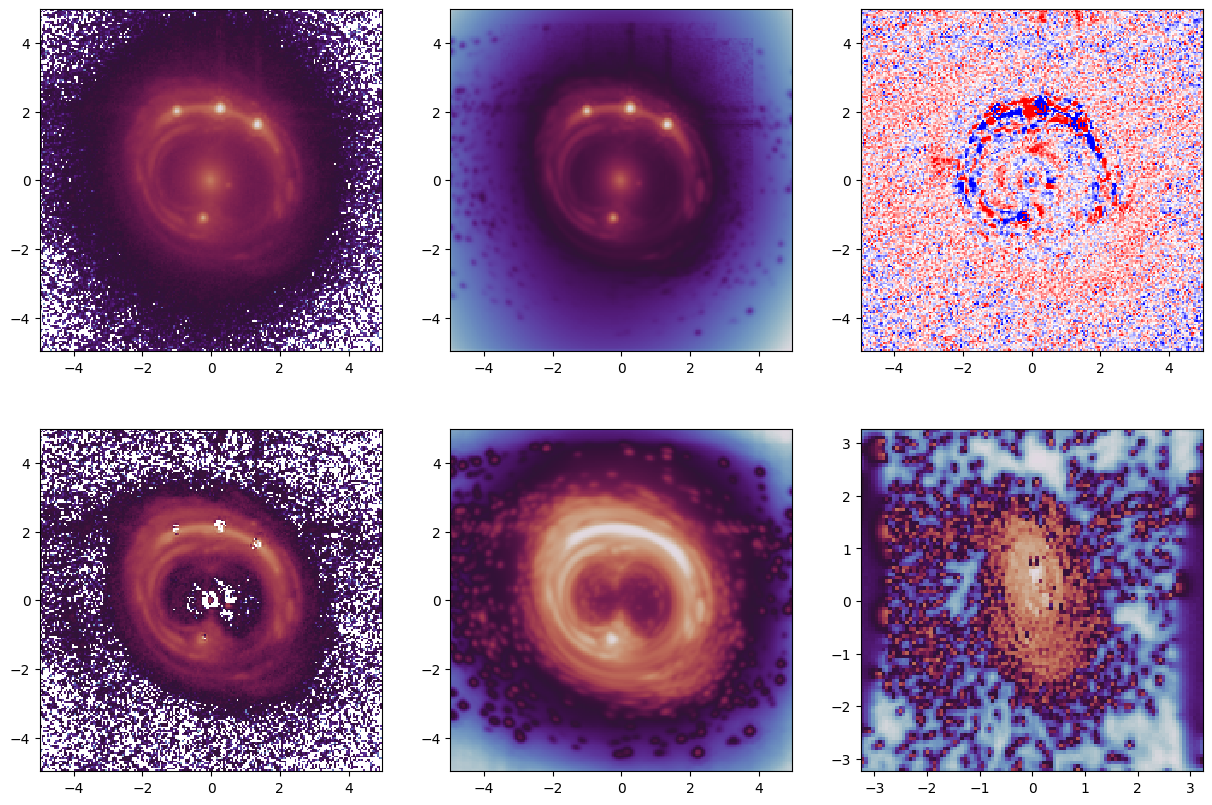

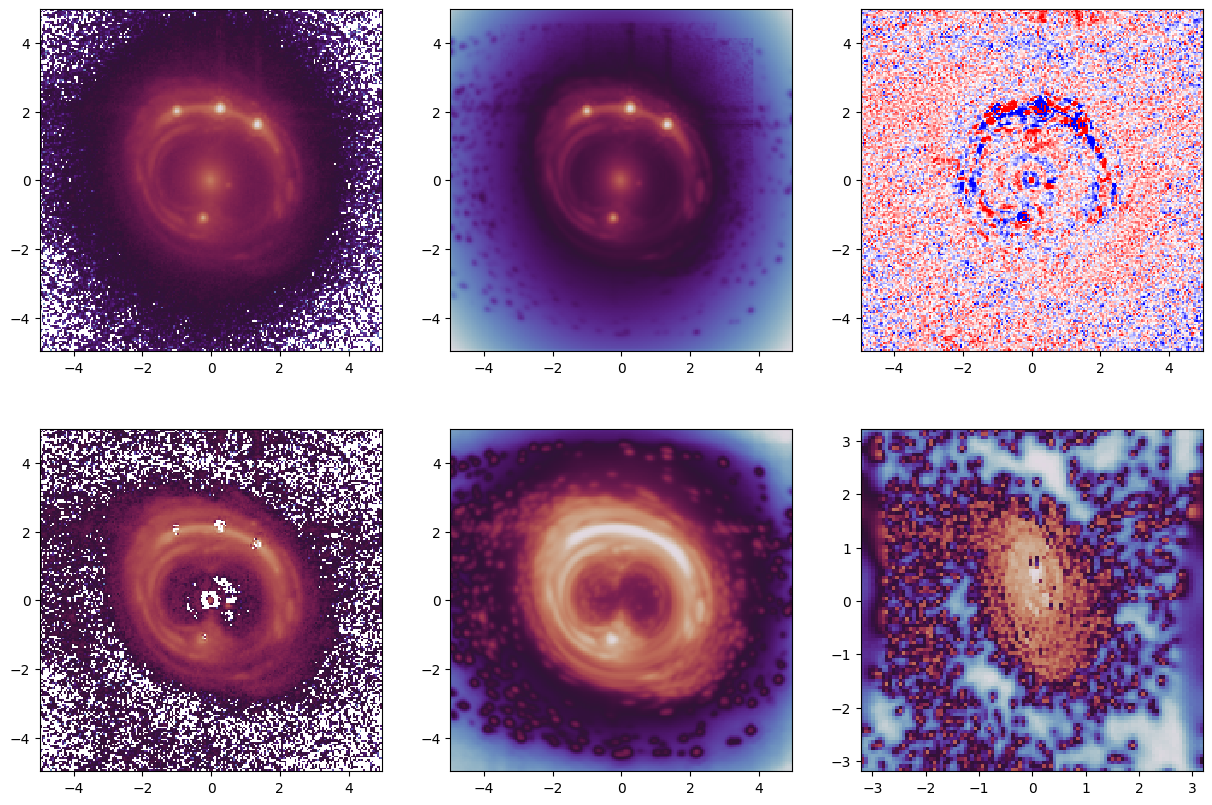

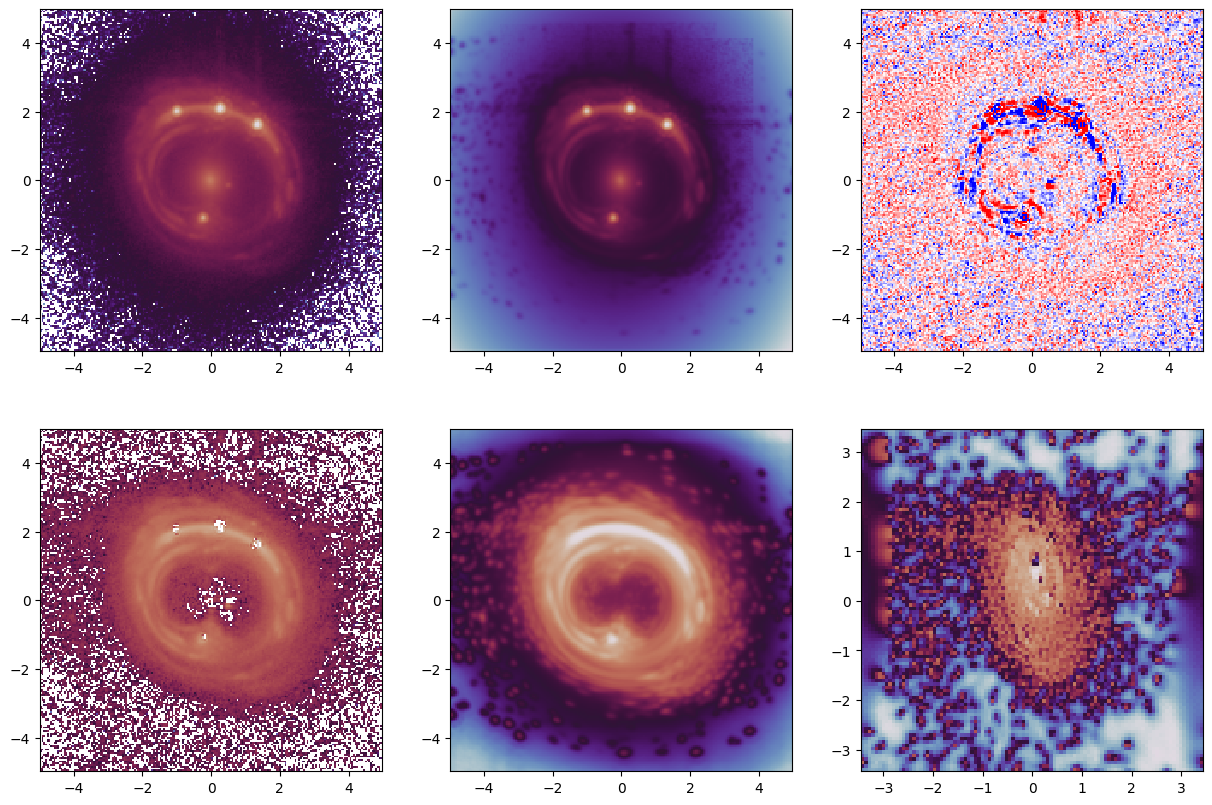

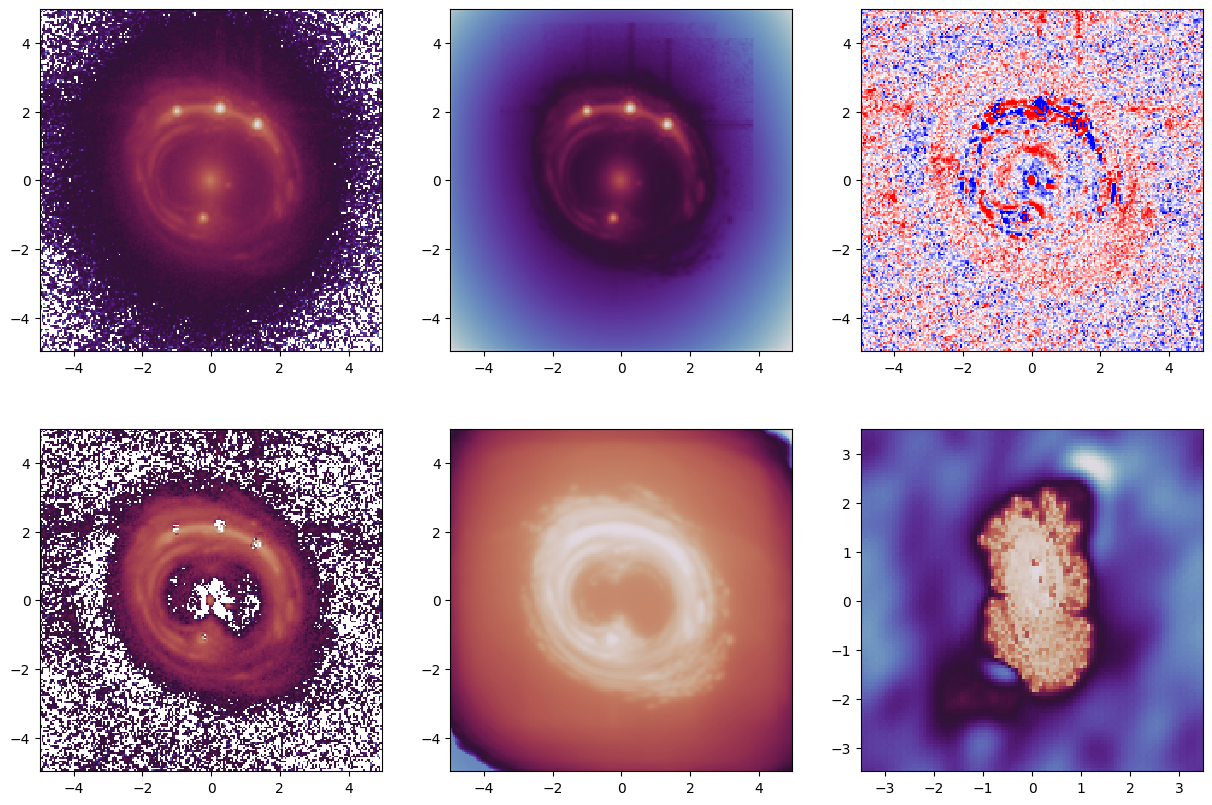

In [14]:
from lens_images_extension import pixelize_plane as pixelize_plane_single
for i in range(4):
    plt.figure(figsize = (15,10))
    plt.subplot(2,3,1)
    plt.imshow(data, norm = 'log', cmap = 'twilight', extent = extent, origin = 'lower')
    plt.subplot(2,3,2)
    image_model = lens_image_pixel.model(**get_value_from_index(multi_svi_pixel_median_herc_stage1, i), source_add = True)
    # image_model = subtract_psf_corner_median(image_model_raw)
    plt.imshow(image_model, norm = 'log', cmap = 'twilight', extent = extent)
    plt.subplot(2,3,3)
    plt.imshow((data - image_model)/rms_file, cmap = 'bwr', vmax = 3, vmin = -3, extent=extent)
    plt.contour(mask, levels=[0.5], colors='black', alpha = 0.95, linewidth = 2, linestyles='dashed', origin='lower', extent=extent)
    plt.subplot(2,3,4)
    lens_light = lens_image_pixel.model(**get_value_from_index(multi_svi_pixel_median_herc_stage1, i), source_add = False)
    plt.imshow(data - lens_light, norm = 'log', cmap = 'twilight', extent = extent)

    plt.subplot(2,3,5)
    plt.imshow(image_model - lens_light, norm = 'log', cmap = 'twilight', extent = extent)
    plt.subplot(2,3,6)
    source, source_extent = pixelize_plane_single(
        lens_image_pixel,
        get_value_from_index(multi_svi_pixel_median_herc_stage1, i),
        pixel_grid_shape,
    )
    plt.imshow(source, extent = source_extent, norm = 'log', cmap = 'twilight')

[2026-02-24 22:42:19] third SVI running
[2026-02-24 22:44:19] third SVI running
[2026-02-24 22:46:19] third SVI running
[2026-02-24 22:48:19] third SVI running
Third SVI runs for 480.004 s which is 8.0 min


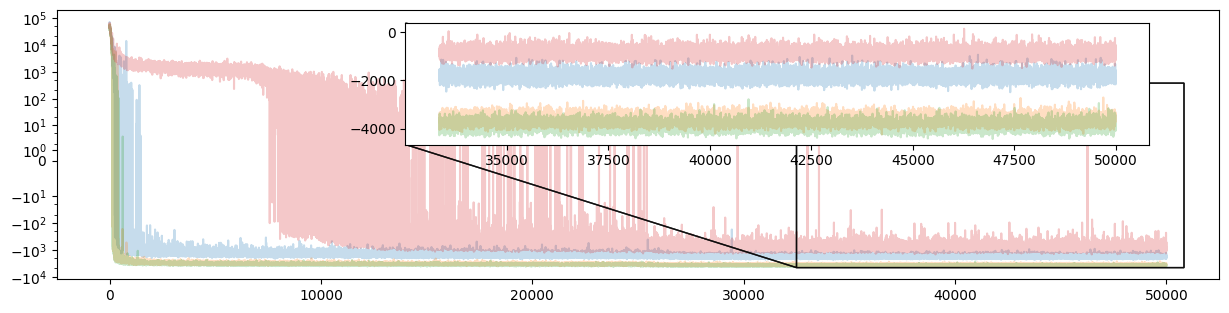

In [15]:
max_iterations = 10000
num_chains = 4

svi_keys = jax.random.split(rng_key_, num_chains)
stage2_results_list = []

for i in range(num_chains):
    init_key_i, run_key_i = jax.random.split(svi_keys[i])
    svi_stage2_i = infer.SVI(model, stage1_guides[i], optim_stage1, loss_stage1)
    # numpyro<=0.15: run(init_state=...) does not call init(), so constrain_fn must be set once.
    _ = svi_stage2_i.init(
        init_key_i,
        data,
        k_grid.k,
        conj=True,
        n_value=None,
        pixelated=True,
        provided_rms=provided_rms,
        mass_prior_kwargs=MASS_PRIOR_PIXELATED,
        psf_kernel_point_source=psf_hst,
    )
    result_i = svi_stage2_i.run(
        run_key_i,
        max_iterations,
        data,
        k_grid.k,
        conj=True,
        n_value=None,
        pixelated=True,
        provided_rms=provided_rms,
        mass_prior_kwargs=MASS_PRIOR_PIXELATED,
        psf_kernel_point_source=psf_hst,
        init_state=stage1_results_list[i].state,
        progress_bar=True,
        stable_update=True,
    )
    stage2_results_list.append(result_i)


def _stack_or_none(*xs):
    if xs[0] is None:
        return None
    return jnp.stack(xs)


multi_svi_pixel_results_stage2 = jax.tree.map(_stack_or_none, *stage2_results_list)
multi_svi_pixel_median_stage2 = guide_pixel_stage1.median(multi_svi_pixel_results_stage2.params)
multi_svi_pixel_median_herc_stage2 = median_params2kwargs(
    lambda p, fixed_params={}: params2kwargs(p, fixed_params=fixed_params, pixelated=True),
    multi_svi_pixel_median_stage2,
    jnp.arange(num_chains),
)

_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_pixel_results_stage2.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)

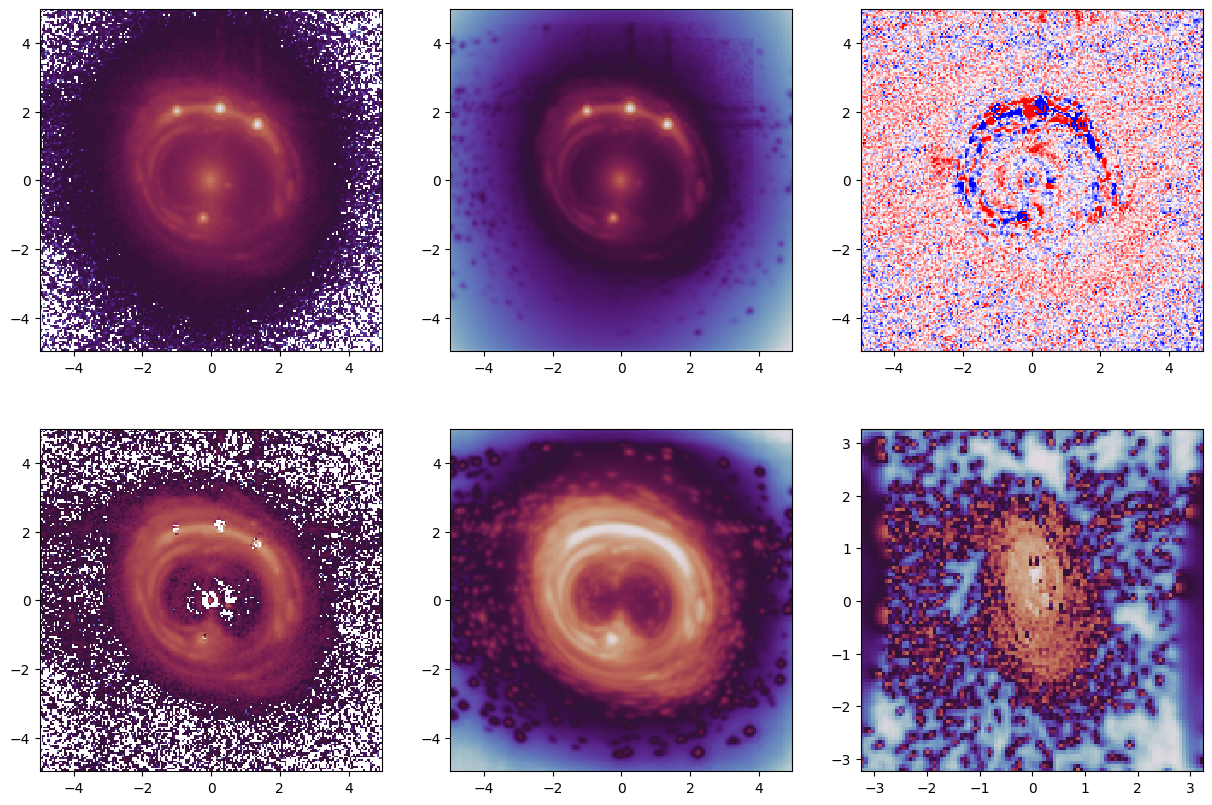

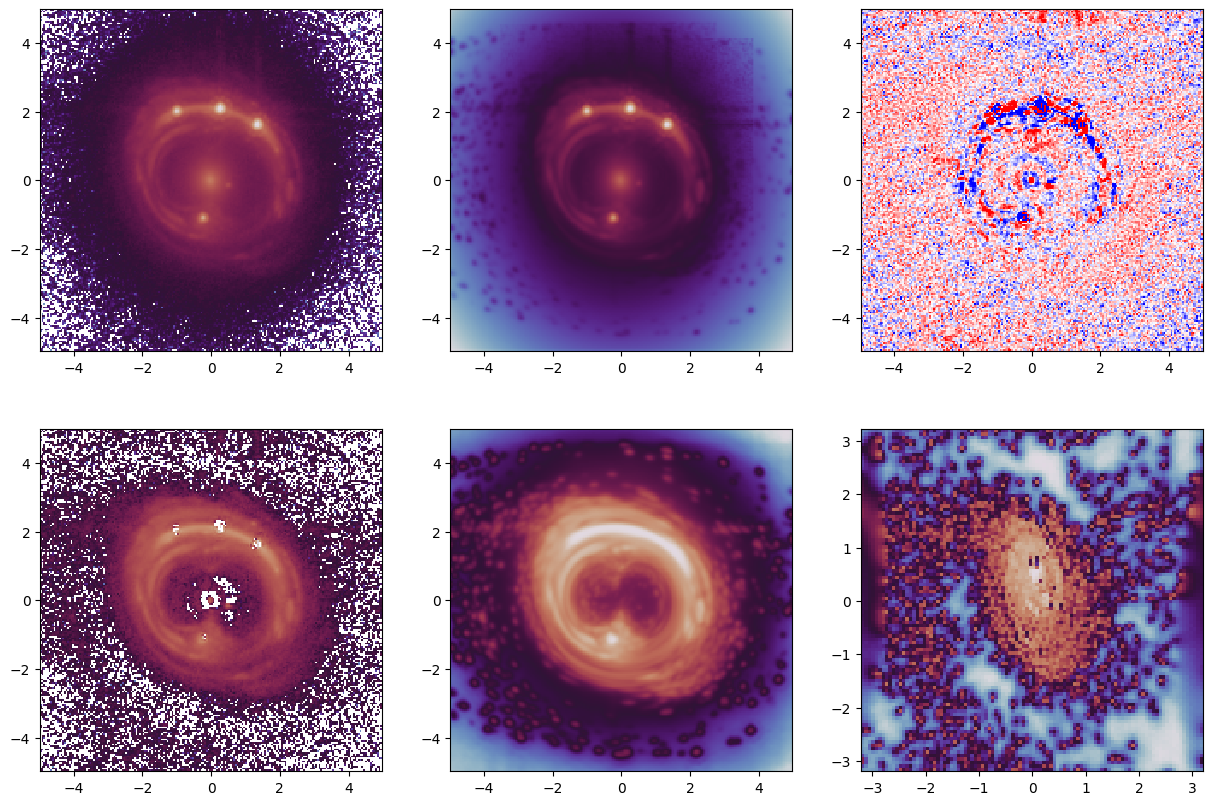

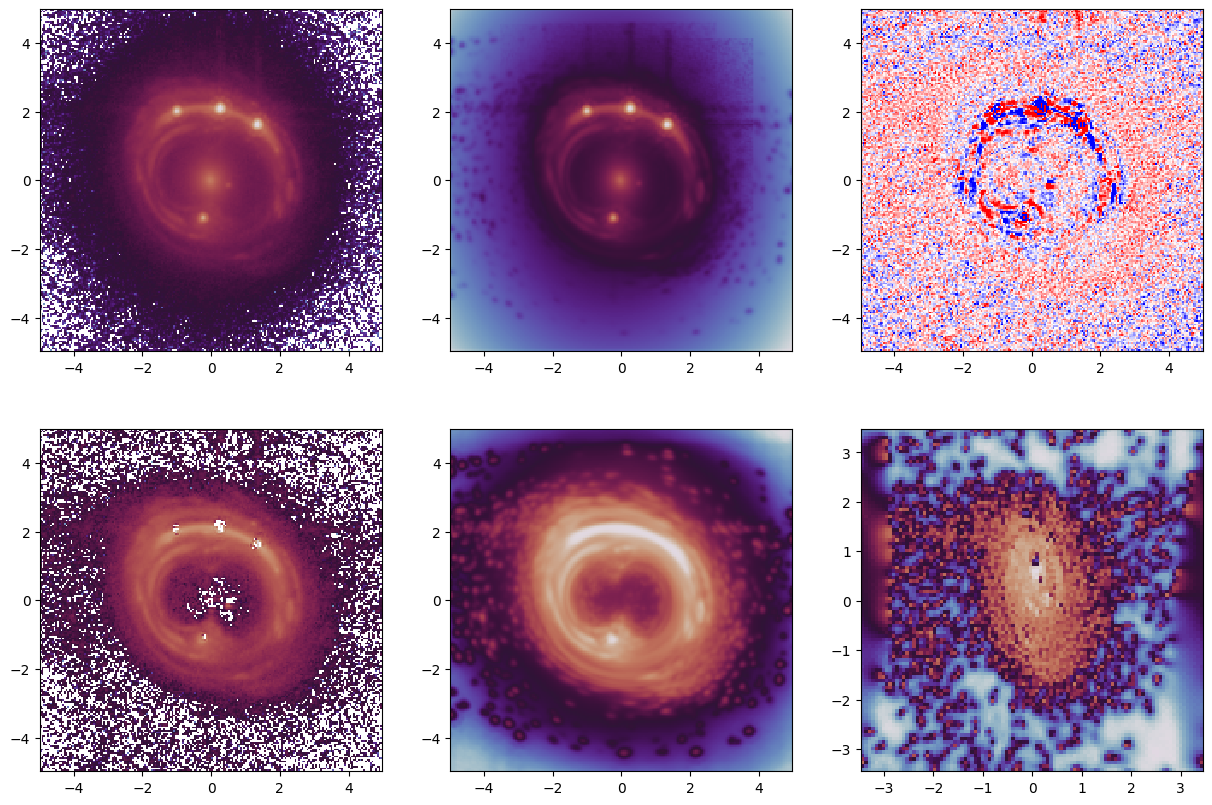

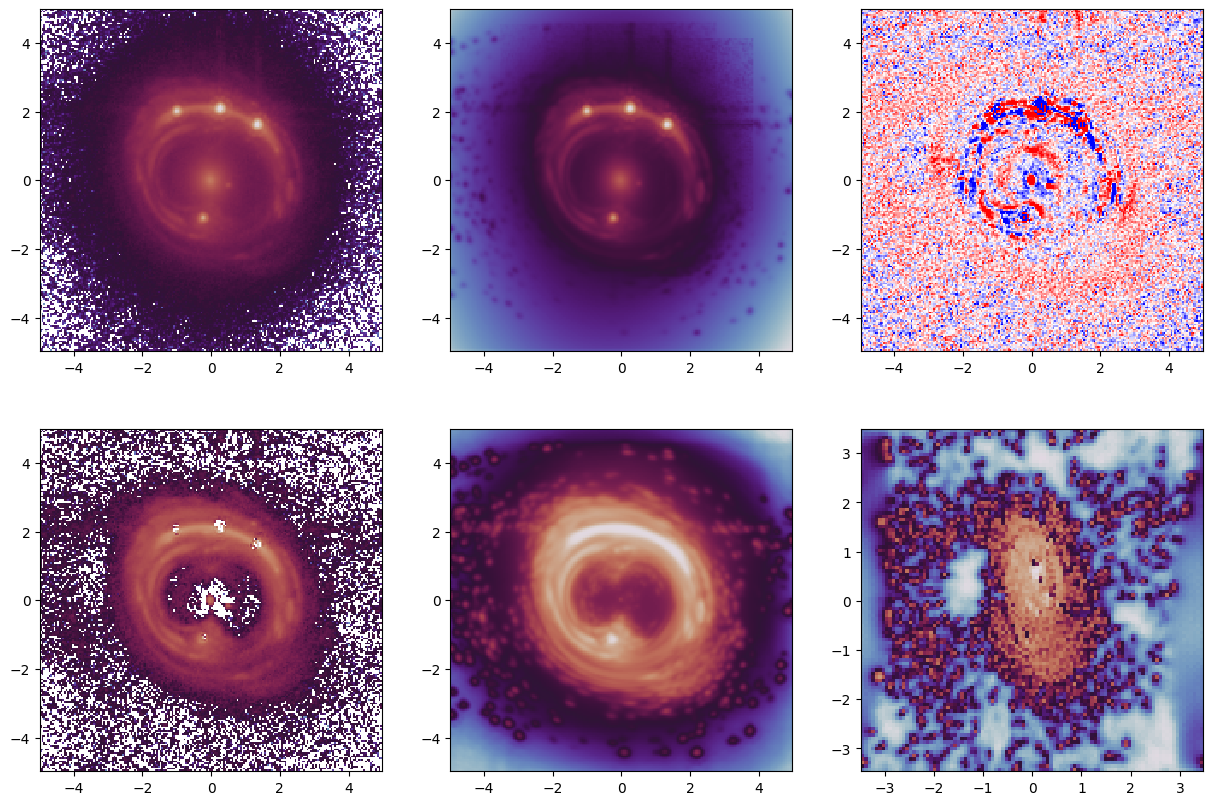

In [16]:
from lens_images_extension import pixelize_plane as pixelize_plane_single

for i in range(4):
    plt.figure(figsize=(15, 10))
    plt.subplot(2, 3, 1)
    plt.imshow(data, norm='log', cmap='twilight', extent=extent, origin='lower')

    plt.subplot(2, 3, 2)
    image_model = lens_image_pixel.model(
        **get_value_from_index(multi_svi_pixel_median_herc_stage2, i),
        source_add=True,
        psf_kernel_point_source=psf_hst,
    )
    plt.imshow(image_model, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 3)
    plt.imshow((data - image_model) / rms_file, cmap='bwr', vmax=3, vmin=-3, extent=extent)
    plt.contour(mask, levels=[0.5], colors='black', alpha=0.95, linewidth=2, linestyles='dashed', origin='lower', extent=extent)

    plt.subplot(2, 3, 4)
    lens_light = lens_image_pixel.model(
        **get_value_from_index(multi_svi_pixel_median_herc_stage2, i),
        source_add=False,
        psf_kernel_point_source=psf_hst,
    )
    plt.imshow(data - lens_light, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 5)
    plt.imshow(image_model - lens_light, norm='log', cmap='twilight', extent=extent)

    plt.subplot(2, 3, 6)
    source, source_extent = pixelize_plane_single(
        lens_image_pixel,
        get_value_from_index(multi_svi_pixel_median_herc_stage2, i),
        pixel_grid_shape,
    )
    plt.imshow(source, extent=source_extent, norm='log', cmap='twilight')

### Corner plot (after third SVI)

In [17]:
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
vars_power = ['rho_source_grid', 'sigma_source_grid']

svi_samples_pixel = guide_pixel_stage1.sample_posterior(rng_key_, multi_svi_pixel_results_stage2.params, sample_shape=(1000,))
svi_samples_pixel_chains = jax.tree.map(lambda x: jnp.swapaxes(x, 0, 1), svi_samples_pixel)
svi_samples_pixel_chains = jax.device_get(svi_samples_pixel_chains)
multi_svi_guide_sample_pixel = az.from_dict(svi_samples_pixel_chains)

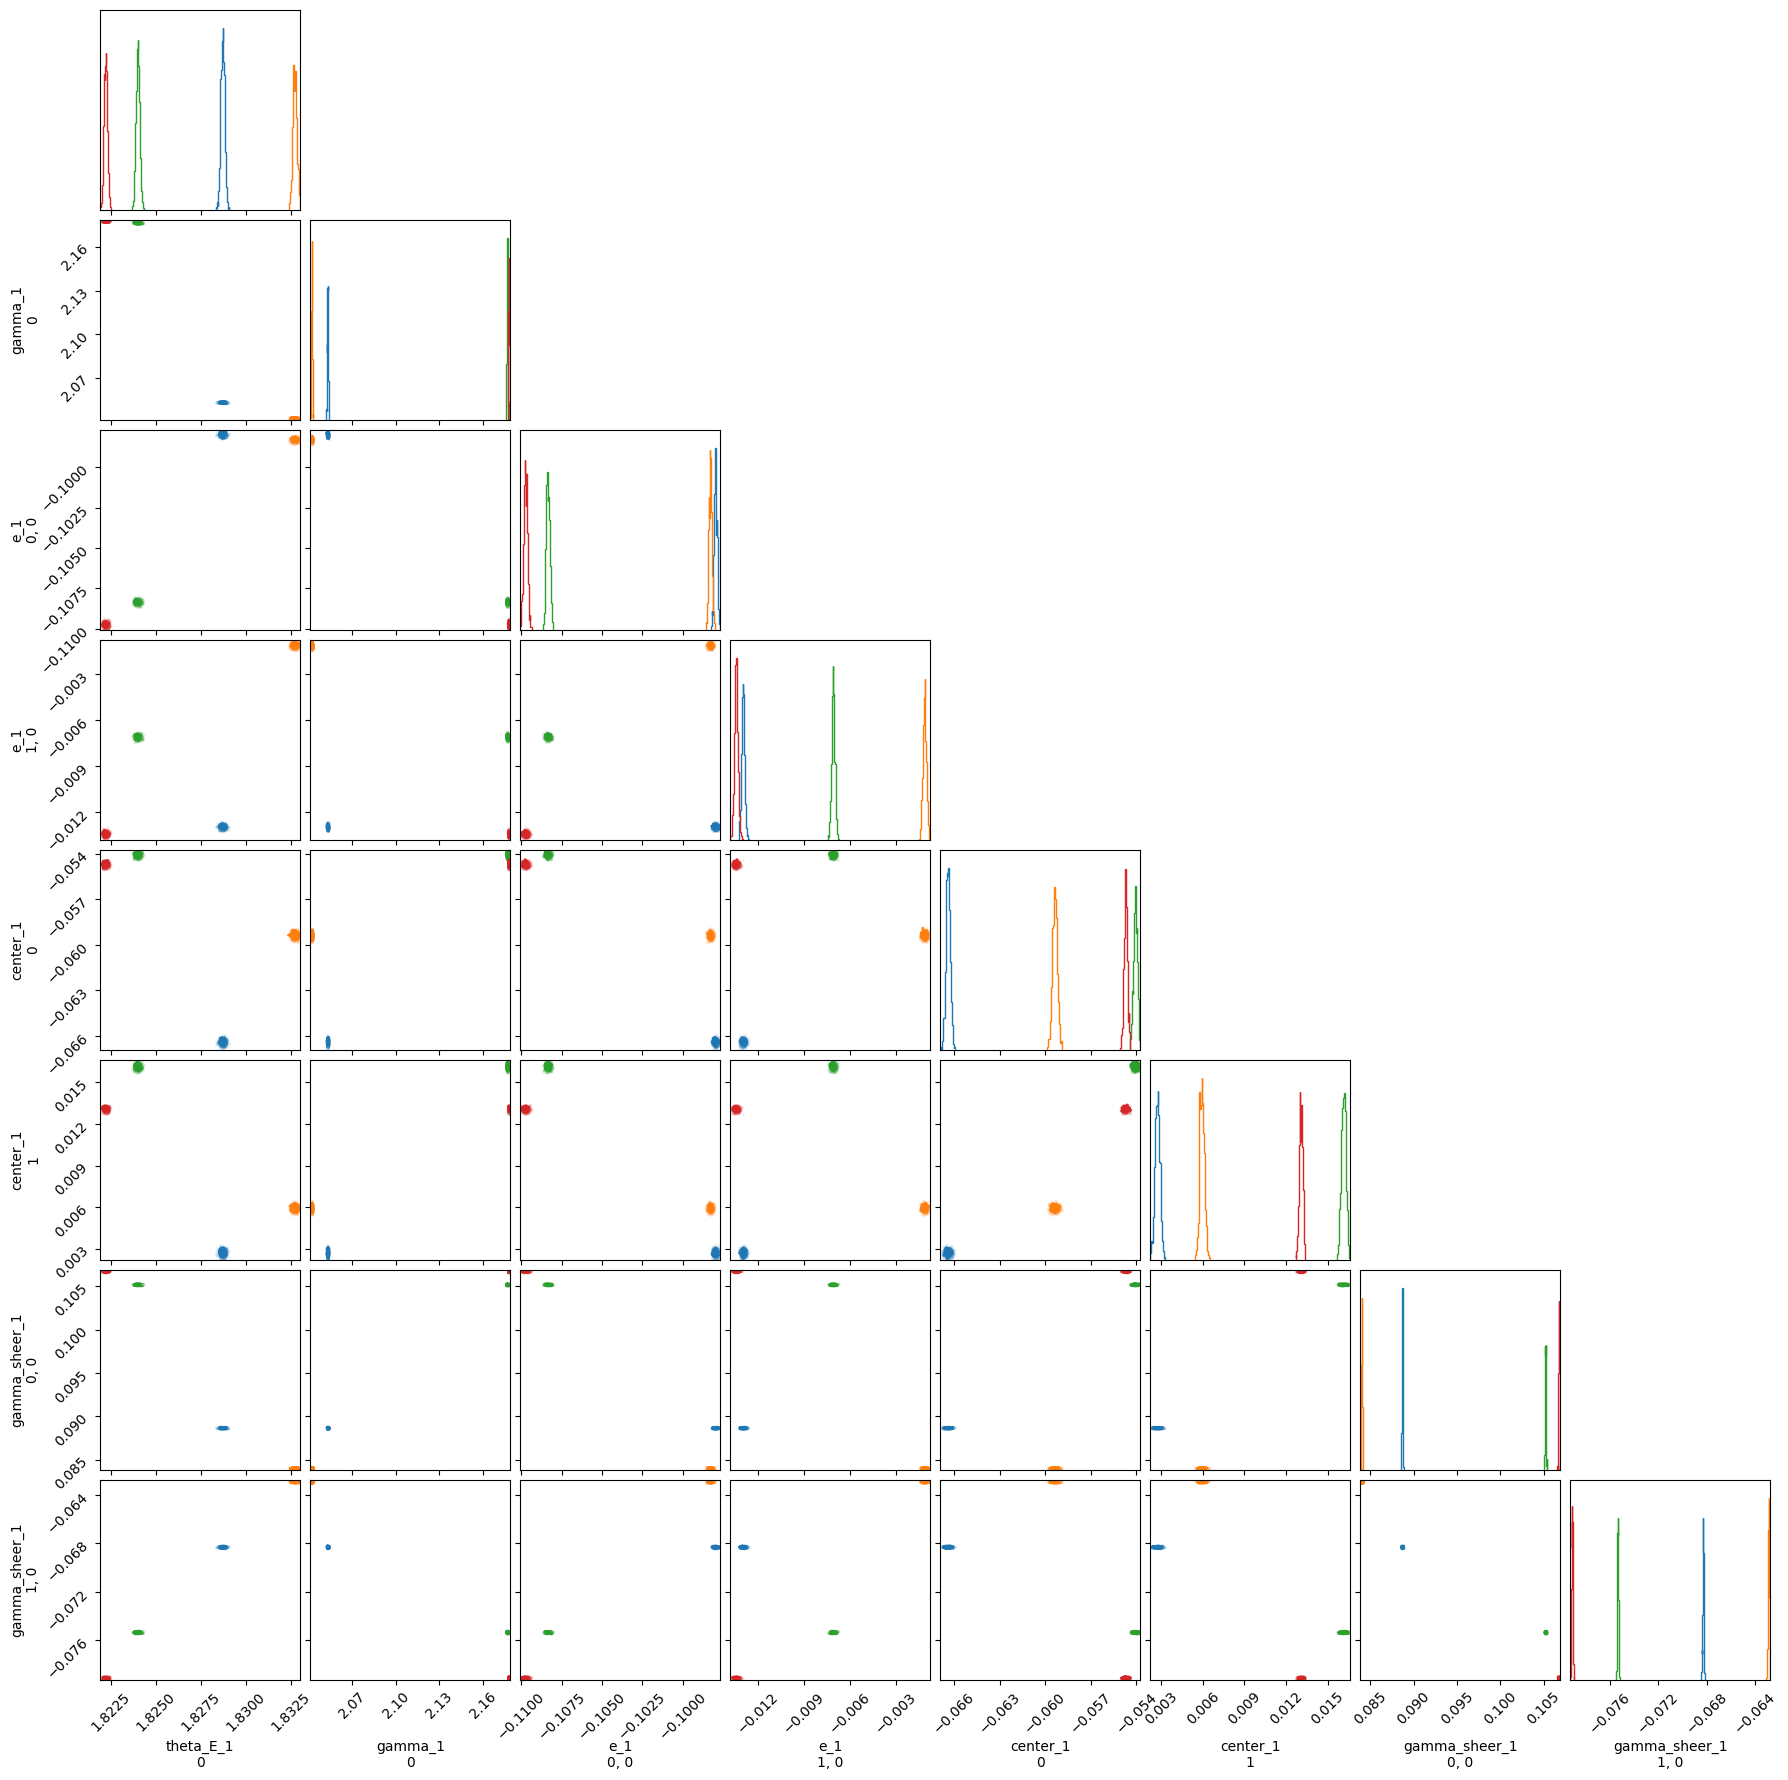

In [18]:
vars_lens_mass = ['theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
fig_corner = None
for i in range(num_chains):
    if i != 5:
        fig_corner = corner(
            multi_svi_guide_sample_pixel.isel(chain=i),
            var_names=vars_lens_mass,
            color=f'C{i}',
            fig=fig_corner,
            # hist_kwargs={'density': True}
        )

# plt.savefig('./result/pixel_svi_posterior.png')

In [18]:
# best_i = int(multi_svi_pixel_results.losses[:, -1000:].mean(axis=1).argmin())

# # lens_light = params2kwargs_gauss_light(get_value_from_index(multi_svi_pixel_median, best_i), 'lens', N_gauss_light, sigma_lims_lens)
# # import pickle

# # with open('lens_light_slice.pkl', 'wb') as f:
# #     pickle.dump(lens_light, f)

# # vars_fixed = vars_lens_light 
# # svi_pixel_median = get_value_from_index(multi_svi_pixel_median, best_i)
# # fixed_params_pixel = {k:svi_pixel_median[k] for k in vars_fixed}
# # model_pixel_hmc_new = condition(model, fixed_params_pixel)

## HMC of the pixel grid model

As with the SVI we can extend the HMC to the full pixel grid model.  Keeping the lens light and parameterized source light fixed at the parameterized SVI solution, and initialize the model with the pixelated SVI solution.  Given the complex 

In [ ]:
vars_pixel = ['pixels_wn_source_grid']
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
vars_psf = ['ra_ps', 'dec_ps', 'log10_amp_ps', 'log10_amp_lens_ps']
multi_svi_pixel_median_vars = {k: multi_svi_pixel_median_stage2[k] for k in vars_mass + vars_power + vars_pixel + vars_other+vars_lens_light+vars_psf}# + 
unconstrined_svi_pixel_median = jax.vmap(lambda p: infer.util.unconstrain_fn(model, (data, k_grid.k), {"pixelated": True, "provided_rms": provided_rms, "mass_prior_kwargs": MASS_PRIOR_PIXELATED}, p))(multi_svi_pixel_median_vars)
#unconstrined_svi_pixel_median_trim = get_value_from_indexs(unconstrined_svi_pixel_median, jnp.array([2, 5, 8, 4]))

unconstrined_svi_pixel_median = {k: v.astype(jnp.float64) for k, v in unconstrined_svi_pixel_median.items()}
rng_key, rng_key_ = jax.random.split(rng_key)

In [ ]:
from numpyro.infer import NUTS, MCMC
from custom_gibbs import MultiHMCGibbs

init_fun_pixel = init_to_value_or_defer(values=get_value_from_index(multi_svi_pixel_median_stage2, 0))

inner_kernels = [
    NUTS(
        model,
        init_strategy=init_fun_pixel,
        target_accept_prob=0.95,
        max_tree_depth=10,
        dense_mass=[('n_source_grid', 'rho_source_grid', 'sigma_source_grid'), 
                    ('A_lens', 'sigma_lens', 'e_lens', 'center_lens'), 
                    ('ra_ps', 'dec_ps', 'log10_amp_ps', 'log10_amp_lens_ps')],
    ),
    NUTS(
        model,
        init_strategy=init_fun_pixel,
        target_accept_prob=0.9,
        max_tree_depth=10,
        dense_mass=[('center_1',), ('theta_E_1',), ('e_1', 'gamma_1', 'gamma_sheer_1')],
    ),
]

outer_kernel = MultiHMCGibbs(
    inner_kernels,
    gibbs_sites_list=[vars_pixel+vars_power+vars_lens_light + vars_other + vars_psf, vars_mass]
)

mcmc_pixel = MCMC(
    outer_kernel,
    num_warmup=100,
    num_samples=100,
    num_chains=num_chains,
    progress_bar=True,
    chain_method='vectorized'
)

batch_number = 4
last_states = []
batch_list = []
for i in range(batch_number):
    if i == 0:
        mcmc_pixel.run(
            rng_key_,
            data,
            k_grid.k,
            conj=False,
            pixelated=True,
            provided_rms=provided_rms,
            mass_prior_kwargs=MASS_PRIOR_PIXELATED,
            init_params=unconstrined_svi_pixel_median
        )
        last_states.append(jax.device_get(mcmc_pixel.last_state))
    else:
        mcmc_pixel.post_warmup_state = mcmc_pixel.last_state
        mcmc_pixel.run(
            mcmc_pixel.post_warmup_state.rng_key,
            data,
            k_grid.k,
            conj=False,
            pixelated=True,
            provided_rms=provided_rms,
            mass_prior_kwargs=MASS_PRIOR_PIXELATED
        )
        last_states.append(jax.device_get(mcmc_pixel.last_state))

    mcmc_pixel._states = jax.device_get(mcmc_pixel._states)
    mcmc_pixel._states_flat = jax.device_get(mcmc_pixel._states_flat)
    mcmc_chain = az.from_numpyro(mcmc_pixel)
    mcmc_chain.to_netcdf("/mnt/lustre/tianli/quasar_hmc/RXJ1131"+str(i)+".nc")
    batch_list.append(mcmc_chain)



In [1]:
import arviz as az
import numpy as np
batch_list = []
for i in range(1):
    # current_batch = az.from_netcdf("/mnt/lustre/tianli/quasar_hmc/RXJ1131_"+str(i)+".nc")
    current_batch = az.from_netcdf("/mnt/lustre/tianli/quasar_hmc/RXJ1131_all.nc")
    batch_list.append(current_batch)
print('concat')  
inf_data_pixel = az.concat(*batch_list, dim='draw')
vars_mass = ['theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_lens_light = ['A_lens', 'sigma_lens', 'e_lens', 'center_lens']
vars_source_light = ['A_source', 'sigma_source', 'e_source']
vars_other = []
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
print(f'divergences per chain per step:\n {inf_data_pixel.sample_stats.diverging.values.sum(axis=1).T}')
#az.summary(inf_data_pixel, var_names=vars_mass + vars_power + vars_other)
az.summary(inf_data_pixel.sel(chain=np.array([0,1,2,3])), var_names=vars_mass + vars_power + vars_other)

concat
divergences per chain per step:
 [[ 0 20 65  0]
 [ 0  0  0  0]]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_E_1[0],1.831,0.001,1.830,1.832,0.000,0.000,7.0,35.0,1.56
gamma_1[0],2.030,0.008,2.017,2.040,0.003,0.002,6.0,25.0,1.81
"e_1[0, 0]",-0.089,0.001,-0.091,-0.086,0.001,0.000,6.0,29.0,1.72
"e_1[1, 0]",-0.013,0.004,-0.018,-0.009,0.002,0.000,5.0,16.0,2.53
center_1[0],-0.060,0.002,-0.062,-0.055,0.001,0.001,5.0,14.0,2.49
center_1[1],0.005,0.001,0.004,0.007,0.000,0.000,6.0,35.0,1.84
"gamma_sheer_1[0, 0]",0.087,0.002,0.084,0.089,0.001,0.000,6.0,29.0,1.88
"gamma_sheer_1[1, 0]",-0.070,0.002,-0.073,-0.066,0.001,0.000,5.0,15.0,2.58
n_source_grid[0],0.002,0.001,0.000,0.004,0.000,0.000,8.0,61.0,1.50
rho_source_grid[0],6.002,4.386,1.487,13.807,0.958,0.713,12.0,47.0,1.28


/tmp/ipykernel_682998/3999965567.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


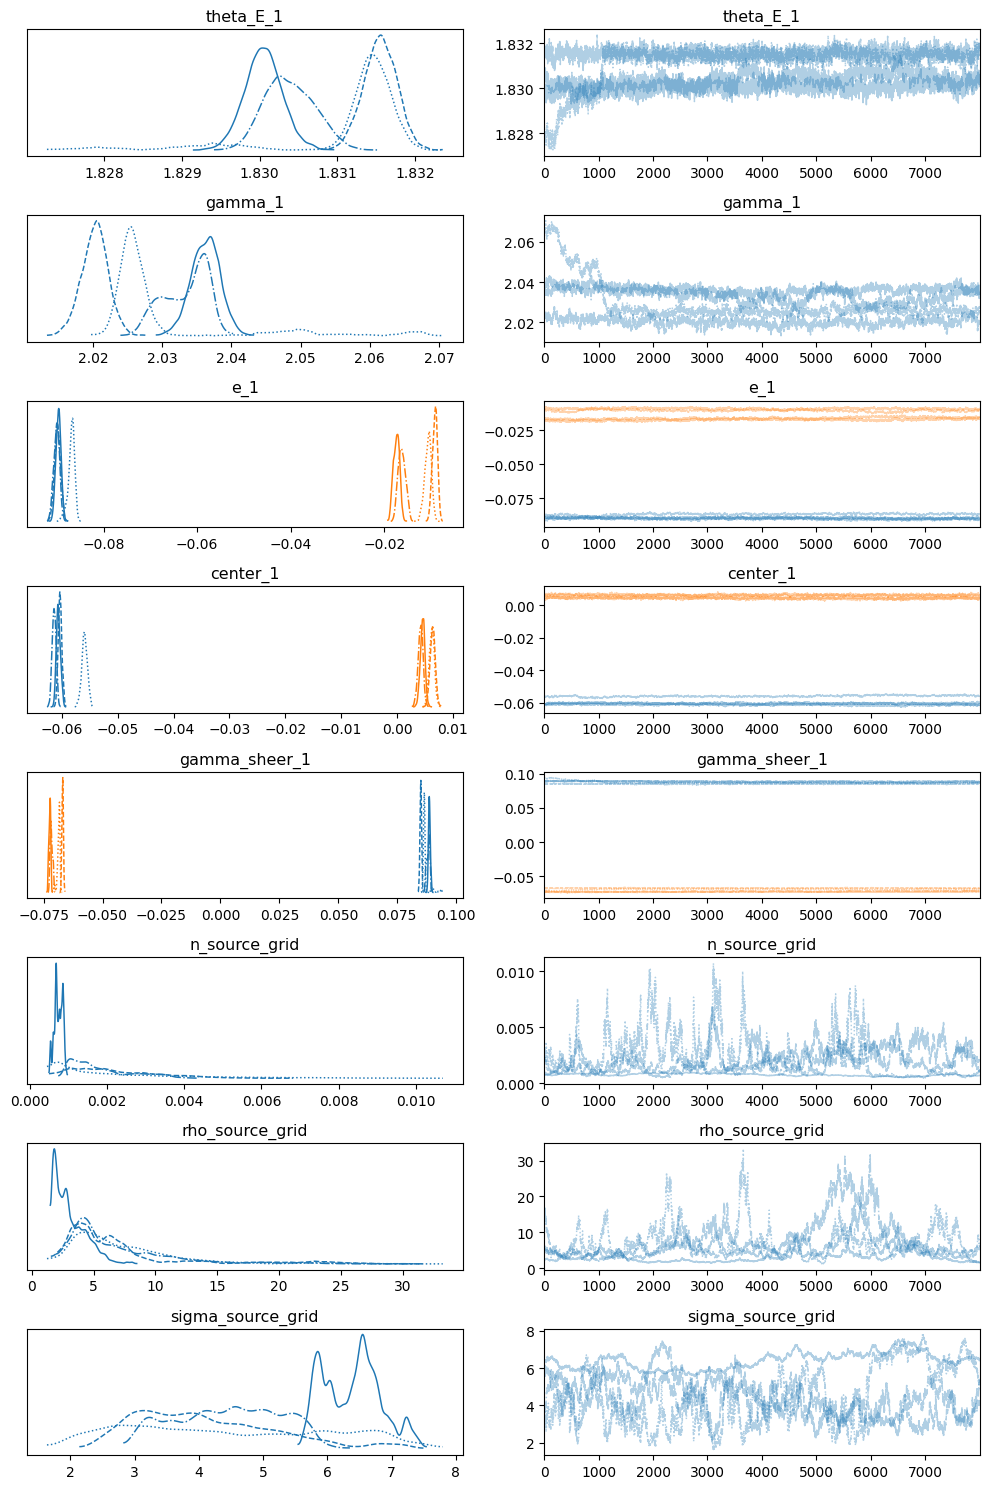

In [3]:
import matplotlib.pyplot as plt

plt.rcParams['figure.constrained_layout.use'] = True
_ = az.plot_trace(inf_data_pixel.sel(chain=np.array([0,1, 2 ,3])),var_names=vars_mass + vars_power + vars_other , figsize=(10, 15))
plt.tight_layout()

In [3]:
%load_ext autoreload
%autoreload 2
import sys
import os
import warnings
warnings.simplefilter("ignore")
# parentdir = os.path.abspath('../..')
# sys.path.insert(0, parentdir) 
from herculens_import_main import *
import jax
import numpyro
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

pix_scale = 0.05  # arcsec / pixel (HST)

DATA_DIR = "../../Data/RXJ1131"
raw_data_path = os.path.join(DATA_DIR, "j8oi74010_drc.fits")
data_path = os.path.join(DATA_DIR, "j8oi74010_drc_cut_x2116_y3377_200_scierr_corner5.fits")
mask_path = os.path.join(DATA_DIR, "mask.fits")
# mask_out is set to all True by design (full image likelihood region)
with fits.open(raw_data_path, memmap=True) as hdul_raw:
    exposure_time = float(hdul_raw[0].header.get("EXPTIME", hdul_raw[0].header.get("TEXPTIME", 1.0)))

with fits.open(data_path, memmap=True) as hdul:
    data = jnp.array(hdul["SCI"].data) if "SCI" in hdul else jnp.array(hdul[0].data)
    rms_file = jnp.array(hdul["ERR"].data)

mask = jnp.array(fits.getdata(mask_path), dtype=bool)
mask_out = jnp.ones_like(data, dtype=bool)
mask =  jnp.array(mask_out, dtype=bool)


corner_pixel = 10
bkg_corner = np.array(data[:corner_pixel, :corner_pixel])
bkg_mean = float(np.nanmean(bkg_corner))
bkg_rms = float(np.nanstd(bkg_corner))

data = data - bkg_mean

[CudaDevice(id=0)]


In [ ]:
for i in range(4):
    plt.figure(figsize = (15,5))
    plt.subplot(1,4,1)
    plt.imshow(data, norm = 'log', cmap = 'twilight', origin = 'lower')
    plt.subplot(1,4,2)
    model_image = inf_data_pixel.posterior.model_image.median(axis = 1)[i,:,:]
    plt.imshow(model_image, norm = 'log', cmap = 'twilight', origin = 'lower')
    plt.subplot(1,4,3)
    plt.imshow((data  - model_image) / rms_file, cmap = 'bwr', vmax = 3, vmin = -3, origin = 'lower')